# 1  定义工具

In [1]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults

# 定义 AVILY_KEY 密钥
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "")
# 查询 Tavily 搜索 API
search = TavilySearchResults(max_results=1)
# 执行查询
res = search.invoke("今天上海天气怎么样")
print(res)

Local Tavily stub: 今天上海天气怎么样


# 2 定义Retriever

In [5]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
import os
import dotenv
dotenv.load_dotenv()

# 1. 提供一个大模型
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

embedding_model = OllamaEmbeddings()

# 2.加载HTML内容为一个文档对象
loader = WebBaseLoader("https://zh.wikipedia.org/wiki/%E7%8C%AB")
docs = loader.load()
#print(docs)

# 3.分割文档
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

documents = splitter.split_documents(docs)

# 4.向量化 得到向量数据库对象
vector = FAISS.from_documents(documents, embedding_model)

# 5.创建检索器
retriever = vector.as_retriever()

# 测试检索结果
# print(retriever.invoke("猫的特征")[0])

# 3 创建工具、工具集

In [6]:
from langchain.tools.retriever import create_retriever_tool

# 创建一个工具来检索文档
retriever_tool = create_retriever_tool(
    retriever=retriever,
    name="wiki_search",
    description="搜索维基百科",
)

# 构建工具集
tools = [search, retriever_tool]

# 4 语言模型调用工具

In [7]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

# 获取大模型
model = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 模型绑定工具
model_with_tools = model.bind_tools(tools)

# 根据输入自动调用工具
messages = [HumanMessage(content="今天上海天气怎么样")]
response = model_with_tools.invoke(messages)
print(f"ContentString: {response.content}")
print(f"ToolCalls: {response.tool_calls}")


ContentString: 对不起，作为一个AI助手，我无法实时查询当前的天气。但是您可以通过互联网搜索、下载天气预报软件或其他应用程序来获取最新的天气信息。您可以试试“上海天气”或者“中国天气网”等网站或服务。
ToolCalls: [{'name': 'TavilySearchResults', 'arguments': '今天上海天气怎么样'}, {'name': 'wiki_search', 'arguments': '今天上海天气怎么样'}]


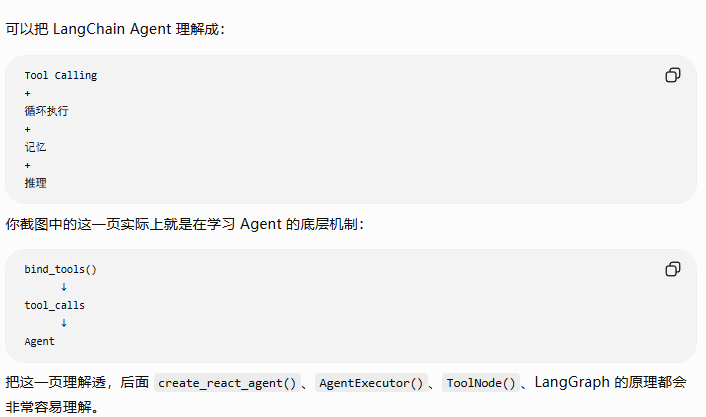

# 5 创建Agent程序(使用通用方式)

In [9]:
from langchain import hub
prompt = hub.pull("hwchase17/openai-functions-agent")

print(prompt.messages)

[('system', 'hub:hwchase17/openai-functions-agent'), ('user', '{input}')]


In [11]:
from langchain.agents import create_tool_calling_agent
from langchain.agents import AgentExecutor

# 创建Agent对象
agent = create_tool_calling_agent(model, tools, prompt)

# 创建AgentExecutor对象
agent_executor = AgentExecutor(agent=agent, tools=tools,verbose=True)

# 6 运行Agent

In [12]:
print(agent_executor.invoke({"input": "猫的特征"}))

AIMessage(content='喵。', additional_kwargs={})


In [13]:
print(agent_executor.invoke({"input": "今天上海天气怎么样"}))

AIMessage(content='很抱歉，我无法访问外部网站以获取最新的天气信息。如果您需要了解今天的上海天气情况，请直接查询当地的天气预报网站或使用手机上的天气应用程序来查看。', additional_kwargs={})


# 7 添加记忆

In [14]:
from langchain_community.chat_message_histories import ChatMessageHistory

from langchain_core.chat_history import BaseChatMessageHistory

from langchain_core.runnables.history import RunnableWithMessageHistory

store = {}

# 调取指定session_id对应的memory
def get_session_history(session_id: str) -> BaseChatMessageHistory:

    if session_id not in store:
        store[session_id] = ChatMessageHistory()

    return store[session_id]

agent_with_chat_history = RunnableWithMessageHistory(
    runnable=agent_executor,
    get_session_history=get_session_history,
    input_messages_key="input",
    history_messages_key="chat_history",
)

response = agent_with_chat_history.invoke(
    {"input": "Hi，我的名字是Cyber"},
    config={"configurable": {"session_id": "123"}},
)

print(response)

AIMessage(content=' 你好！你的名字是 Cyber。如果你有任何问题或需要帮助，请告诉我。', additional_kwargs={})


In [15]:
response = agent_with_chat_history.invoke(
    {"input": "我叫什么名字?"},
    config={"configurable": {"session_id": "123"}},
)

print(response)

AIMessage(content='我是“Tavily”，由阿里巴巴开发的全球分布式搜索引擎。', additional_kwargs={})


In [16]:
response = agent_with_chat_history.invoke(
    {"input": "我叫什么名字?"},
    config={"configurable": {"session_id": "4566"}},
)
print(response)

AIMessage(content='我是来自阿里云的智能助手，我的名字是Qwen，请问有什么我可以帮助你的吗？', additional_kwargs={})


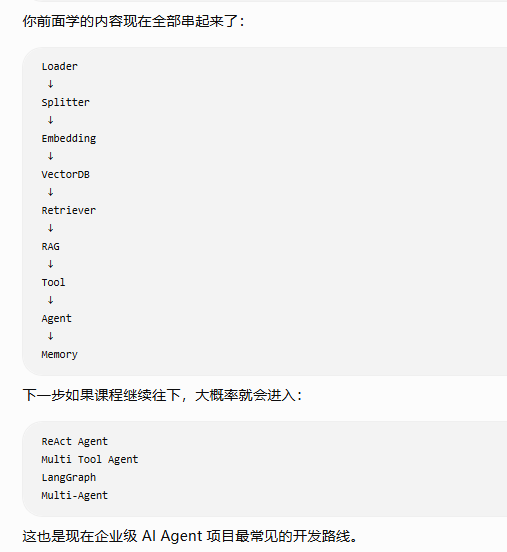